# Training and testing

This notebook focuses on training our ML algorithm to screen whether a player is at risk of gambling-related behavioral problems. It will do so by observing the players' actions while gambling. These actions are then fed into an XGBoost ML algorithm trained on real gambling data from our Bustabit dataset. The features that the game will record are behaviors that scientists use to determine at risk gambling patterns through gameplay. These actions are then fed to our XGBoost at risk gambling screening model. 

## The steps:

1. First, we will create a table that has all of the “players_stats” that will have each row be a summerization of their betting behaviors using measurable features (loss chasing, average bet size, etc...)
2. Create a column for every player that shows whether a player is at risk of being addicted to gambling (low, medium, or high).
3. Create an SMOTE class-balancing step, since most players are low risk based on the data visualization we did in previous notebooks.
4. Training and Testing using Stratified 5-fold cross-validation [K-fold cross-validation]
5. Train the XGBoost model on the training data after K-fold to demonstrate that the approach actually works.
6. Measure how well the model performs using charts and other metrics.

### Important!
    This is just a screening tool to help people who might be at risk of a gambling behavior issue by flagging behavior patterns that are associated with at-risk gambling. The idea is to give those people support resources and not label them as addicts.  

In [12]:
import pandas as pd
from poker_coach.config import BUSTABIT_DATA_FILE
from poker_coach.utils import rainbow


df = pd.read_csv(BUSTABIT_DATA_FILE, parse_dates=['PlayDate'])

## Step 1: Create the player_stats table

    This table is grouped by each player’s Username.
    It shows a summarization of gameplay betting behaviors. Behaviors such as average bet, maximum bet, bet volatility, total sessions, win rate, and total profit.

In [13]:
from poker_coach.config import BITS_PER_BTC, BTC_USD_RATE

df['Won'] = df['CashedOut'].notna()   # missing CashedOut = player busted (lost)
df['NetProfit'] = df['Profit'].fillna(-df['Bet'])   # busted rounds have no Profit recorded, but the full bet is lost

# Bet/Profit are recorded in bits (1 bit = 0.000001 BTC), convert to BTC so the values read as real money
df['Bet_BTC'] = df['Bet'] / BITS_PER_BTC
df['NetProfit_BTC'] = df['NetProfit'] / BITS_PER_BTC

# a "session" is a calendar day played, not a single bet, so group PlayDate down to the day first
df['PlayDay'] = df['PlayDate'].dt.date

player_betting_behavior = df.groupby('Username').agg(
    average_bet = ('Bet_BTC', 'mean'),
    max_bet = ('Bet_BTC', 'max'),
    bet_volatility = ('Bet_BTC', 'std'),
    total_sessions=('PlayDay', 'nunique'),
    win_rate=('Won', 'mean'), 
    total_profit=('NetProfit_BTC', 'sum'),
).reset_index()

rainbow(player_betting_behavior, 20, 'sample')

,Username,average_bet,max_bet,bet_volatility,total_sessions,win_rate,total_profit
2865,joppo,0.000001,0.000001,0.000000,5,0.700000,0.000008
2884,juv,0.001000,0.001000,nan,1,1.000000,0.000054
2282,cherrymobilej1,0.000123,0.000123,nan,1,1.000000,0.000027
525,Dreamsinreality,0.005750,0.050000,0.011653,15,0.590909,-0.001430
3272,nguyenthihanh,0.000556,0.002662,0.001178,5,0.000000,-0.002779
3430,pussydestroyer69,0.000367,0.000600,0.000225,2,0.666667,-0.000371
642,GOLOJO,0.000302,0.002000,0.000528,9,0.357143,-0.001486
1808,VerserrThePepper,0.001399,0.004900,0.002346,2,1.000000,0.002317
654,Gannicus,0.000091,0.001024,0.000188,10,0.857143,0.000309
3665,skam93,0.000001,0.000001,0.000000,3,1.000000,0.000000


Identical version of the table above, converted to USD.

In [14]:
df['Bet_USD'] = df['Bet_BTC'] * BTC_USD_RATE
df['NetProfit_USD'] = df['NetProfit_BTC'] * BTC_USD_RATE


player_betting_behavior_usd = df.groupby('Username').agg(
    average_bet = ('Bet_USD', 'mean'),
    max_bet = ('Bet_USD', 'max'),
    bet_volatility = ('Bet_USD', 'std'),
    total_sessions=('PlayDay', 'nunique'),
    win_rate=('Won', 'mean'), 
    total_profit=('NetProfit_USD', 'sum'),
).reset_index()

rainbow(player_betting_behavior_usd, 20, 'sample')

,Username,average_bet,max_bet,bet_volatility,total_sessions,win_rate,total_profit
626,FreakFruit,0.036095,0.504000,0.089052,17,0.127273,0.295425
2499,edwardteach2,0.380250,2.481750,0.616942,5,0.588235,3.925245
4029,winningsBETLUCK,2.000000,3.750000,1.561249,2,0.666667,4.762830
3823,thatboredguy999,0.106413,0.972750,0.229448,8,0.307692,-0.973815
69,917,0.097500,0.105000,0.010607,2,0.000000,-0.195000
2422,dima00888,0.020812,0.075000,0.036199,2,0.000000,-0.083250
1843,WeinervilleUSA,0.600000,0.600000,nan,1,1.000000,0.036000
2883,juuUanfran99,0.027000,0.045000,0.022504,4,0.428571,-0.106845
1730,Tienquang,1.082500,3.000000,1.661827,1,0.666667,-2.810182
2696,haihien999,1.965750,8.333250,2.726885,5,0.500000,-2.522017


Bring in loss_chase_rate the same way notebook 02 found it (bet increased right after a loss), but per player instead of across everyone. Then player_stats is the USD table plus that column, and that's the table the rest of this notebook trains on.

In [15]:
from poker_coach.config import PLAYER_STATS_FILE

df = df.sort_values(['Username', 'PlayDate']).reset_index(drop=True)
df['PrevBet'] = df.groupby('Username')['Bet'].shift(1)
df['PrevWon'] = df.groupby('Username')['Won'].shift(1)
df['BetIncreased'] = df['Bet'] > df['PrevBet']

seq_df = df.dropna(subset=['PrevWon', 'PrevBet']).copy()
after_loss_df = seq_df[seq_df['PrevWon'] == False]   # only the bets that came right after a loss

loss_chase_rate = after_loss_df.groupby('Username')['BetIncreased'].mean().rename('loss_chase_rate')
print(f"{len(loss_chase_rate):,} of {len(player_betting_behavior_usd):,} players had at least one bet after a loss")

player_stats = player_betting_behavior_usd.merge(loss_chase_rate, on='Username', how='left')

# no after-loss bets to look at, or only ever placed one bet -> nothing to measure, treat as no signal instead of dropping the player
player_stats['bet_volatility'] = player_stats['bet_volatility'].fillna(0)
player_stats['loss_chase_rate'] = player_stats['loss_chase_rate'].fillna(0)

player_stats.to_csv(PLAYER_STATS_FILE, index=False)
rainbow(player_stats, 20, 'sample')

2,229 of 4,149 players had at least one bet after a loss


,Username,average_bet,max_bet,bet_volatility,total_sessions,win_rate,total_profit,loss_chase_rate
3135,mccriddle,0.076125,0.225000,0.068084,6,0.875000,0.196552,1.000000
869,Jezzah87,0.058125,0.090000,0.045078,1,0.500000,-0.017250,1.000000
2239,butaw,0.850000,0.975000,0.114564,3,0.666667,-0.507113,1.000000
1860,Wolf_gang,7.500000,7.500000,0.000000,1,1.000000,7.609147,0.000000
2432,diseasedlogic,0.008250,0.008250,0.000000,1,1.000000,0.000412,0.000000
1615,Snowballcps,0.107599,1.575750,0.259282,11,0.879310,-0.385972,0.000000
257,BitCoinGoals,0.405375,0.418500,0.018562,2,0.000000,-0.810750,1.000000
3105,mark09,3.791625,15.000000,5.699629,4,0.666667,-18.350280,0.000000
2756,igorvip2,0.003000,0.006750,0.003269,1,1.000000,0.004403,0.000000
674,Gillyp16,0.675000,0.675000,0.000000,1,1.000000,0.840158,0.000000


## Step 2: Label each player's RiskTier

    There's no ground-truth "this player is addicted" column anywhere, so we build one out of research-backed warning signals instead: loss chasing, how erratic their bet sizes are, and how often they're playing. A player gets one point per signal they trip, and the point total maps to Low / Moderate / High.

    Honesty check: this is a rule-based label built from measurable thresholds, not a clinical diagnosis. We're operationalizing DSM-5-aligned risk signals into numbers we can actually compute from the data, same as we talked about with the fairness question on the milestone.

    Leakage check: loss_chase_rate, bet_volatility, and total_sessions define this label directly, so none of the three can also be a training feature later — the model would just be relearning our own thresholds instead of finding real patterns. Step 3 drops all three from FEATURE_COLUMNS for exactly that reason.

In [16]:
# 75th percentile = "high" relative to everyone else in this dataset, not an absolute cutoff
volatility_threshold = player_stats['bet_volatility'].quantile(0.75)
sessions_threshold = player_stats['total_sessions'].quantile(0.75)

signals = (
    (player_stats['loss_chase_rate'] > 0.50).astype(int)
    + (player_stats['bet_volatility'] > volatility_threshold).astype(int)
    + (player_stats['total_sessions'] > sessions_threshold).astype(int)
)

def signals_to_tier(signal_count):
    if signal_count >= 3:
        return 'High'
    elif signal_count >= 1:
        return 'Moderate'
    else:
        return 'Low'

player_stats['RiskTier'] = signals.apply(signals_to_tier)

player_stats['RiskTier'].value_counts()

RiskTier
Low         2315
Moderate    1730
High         104
Name: count, dtype: int64

## Step 3: Train/test split, then SMOTE on the training half only

    High risk players are rare, so splitting first and balancing second matters a lot here. SMOTE has to be fit only on the training data — if it runs before the split, synthetic points built from the test players leak into training and the test score stops meaning anything. The test set stays exactly as imbalanced as real life.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# loss_chase_rate, bet_volatility, and total_sessions built RiskTier itself, so they're left out here -
# training on them would just teach the model our own thresholds back, not real signal
FEATURE_COLUMNS = ['average_bet', 'max_bet', 'win_rate', 'total_profit']

X = player_stats[FEATURE_COLUMNS]

risk_encoder = LabelEncoder()
y = risk_encoder.fit_transform(player_stats['RiskTier'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"train: {len(X_train):,} players, test: {len(X_test):,} players")
print("train RiskTier counts:", pd.Series(risk_encoder.inverse_transform(y_train)).value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("balanced train RiskTier counts:", pd.Series(risk_encoder.inverse_transform(y_train_balanced)).value_counts().to_dict())

train: 3,319 players, test: 830 players
train RiskTier counts: {'Low': 1852, 'Moderate': 1384, 'High': 83}
balanced train RiskTier counts: {'Low': 1852, 'Moderate': 1852, 'High': 1852}


## Step 4: Stratified 5-fold cross-validation

    One split could just get lucky (or unlucky) with where the handful of High risk players land, so this runs 5 different train/validation splits and averages them. Stratified keeps the Low/Moderate/High proportions the same in every fold so High risk players actually show up in each one.

    SMOTE gets refit inside every fold on that fold's training slice only — reusing the single balanced set from Step 3 across all 5 folds would leak the same synthetic neighbors into whichever fold happens to validate on them, which is the same leakage problem as before, just one level down.

    Low std across folds = the model is stable no matter how the data gets split. High std = it's just getting lucky sometimes.

In [18]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

fold_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, eval_metric='mlogloss')),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies, fold_f1s = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    fold_pipeline.fit(X_train.iloc[train_idx], y_train[train_idx])
    val_preds = fold_pipeline.predict(X_train.iloc[val_idx])

    fold_accuracy = accuracy_score(y_train[val_idx], val_preds)
    fold_f1 = f1_score(y_train[val_idx], val_preds, average='macro')
    fold_accuracies.append(fold_accuracy)
    fold_f1s.append(fold_f1)
    print(f"Fold {fold}: accuracy {fold_accuracy:.2f}, F1 {fold_f1:.2f}")

print(f"\nMean accuracy: {np.mean(fold_accuracies):.3f}, std: {np.std(fold_accuracies):.3f}")
print(f"Mean F1: {np.mean(fold_f1s):.3f}, std: {np.std(fold_f1s):.3f}")

Fold 1: accuracy 0.79, F1 0.63
Fold 2: accuracy 0.79, F1 0.65
Fold 3: accuracy 0.75, F1 0.60
Fold 4: accuracy 0.79, F1 0.62
Fold 5: accuracy 0.76, F1 0.61

Mean accuracy: 0.776, std: 0.017
Mean F1: 0.622, std: 0.019


## Step 5: Train the model we'll actually use

    K-fold above was just proving the approach holds up across different splits. This step trains the real thing: one XGBoost model on the full balanced training set, saved to disk so it can screen new players without retraining.

In [19]:
import joblib
from poker_coach.config import MODELS_DIR, RISK_SCREENER_MODEL_FILE

model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, eval_metric='mlogloss')
model.fit(X_train_balanced, y_train_balanced)

MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(model, RISK_SCREENER_MODEL_FILE)
print(f"model saved to {RISK_SCREENER_MODEL_FILE.relative_to(MODELS_DIR.parent)}")

model saved to models/xgboost_risk_screener.pkl


## Step 6: Evaluation on the untouched test set

    Accuracy alone hides how the model does on the class we actually care about, so we look at precision/recall/F1 per tier, a confusion matrix, and feature importance.

    Careful with what "recall on High" actually means: it's how often the model reproduces our own RiskTier rule, not whether it caught a real at-risk gambler — RiskTier was never checked against anything outside that rule. Since loss_chase_rate/bet_volatility/total_sessions built the label and aren't training features anymore, this at least tests whether *other* behaviors (bet size, win rate, profit) can predict the label, instead of the model just reading its own thresholds back. And with only 21 High-risk players in the test set, every number below is a rough signal from a tiny sample, not something to act on as-is.

In [20]:
from sklearn.metrics import classification_report

test_preds = model.predict(X_test)

RISK_TIER_ORDER = ['Low', 'Moderate', 'High']
tier_labels = risk_encoder.transform(RISK_TIER_ORDER)

print(classification_report(y_test, test_preds, labels=tier_labels, target_names=RISK_TIER_ORDER))

              precision    recall  f1-score   support

         Low       0.88      0.86      0.87       463
    Moderate       0.77      0.68      0.72       346
        High       0.22      0.81      0.35        21

    accuracy                           0.78       830
   macro avg       0.62      0.78      0.65       830
weighted avg       0.82      0.78      0.79       830



Confusion matrix - which RiskTiers actually get mixed up with each other.

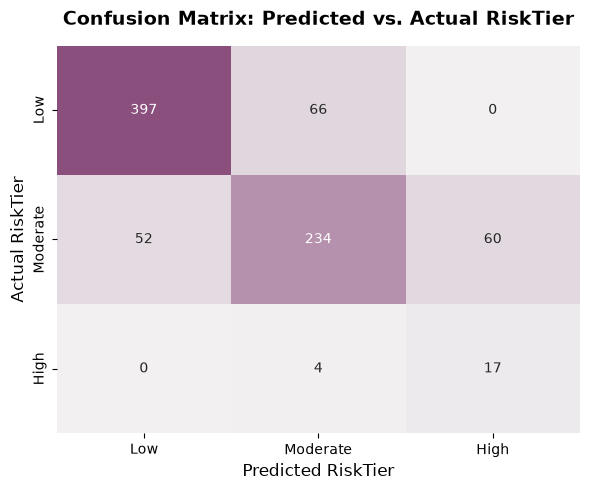

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from poker_coach.config import GRAPE_SODA

cm = confusion_matrix(y_test, test_preds, labels=tier_labels)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(GRAPE_SODA, as_cmap=True),
                  xticklabels=RISK_TIER_ORDER, yticklabels=RISK_TIER_ORDER, cbar=False)

plt.title('Confusion Matrix: Predicted vs. Actual RiskTier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted RiskTier', fontsize=12)
plt.ylabel('Actual RiskTier', fontsize=12)
plt.tight_layout()
plt.show()

Feature importance - which behaviors the model actually leaned on.

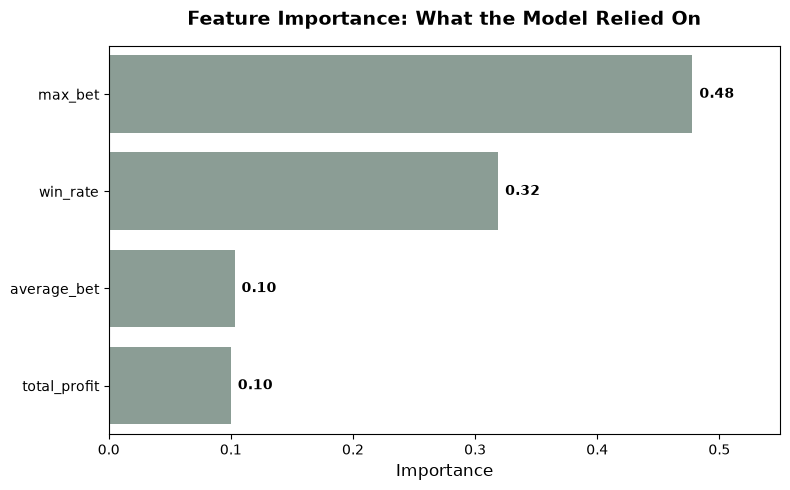

In [22]:
from poker_coach.config import MUTED_TEAL

importance_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=importance_df, x='importance', y='feature', color=MUTED_TEAL)

plt.title('Feature Importance: What the Model Relied On', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('')
plt.xlim(0, max(importance_df['importance']) * 1.15)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()